g:\mp\Decoding-Au-clusters\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Generating synthetic atomic coordinates for Radius of Gyration parity...

          RUNNING REFERENCE FRAMEWORK (MDAnalysis)
-> MDAnalysis Rg: 8.541368

          RUNNING DIMREDPY FRAMEWORK
-> DimRedPy Rg: 8.541368

          PARITY VALIDATION
MSE on Radius of Gyration: 8.01e-20

SUCCESS: DimRedPy Radius of Gyration perfectly matches MDAnalysis reference.
Saved comparison plot to g:\mp\Decoding-Au-clusters\dimredpy_vs_others\dimredpy_vs_descriptors\verify_parity_descriptors_rg_plot.png


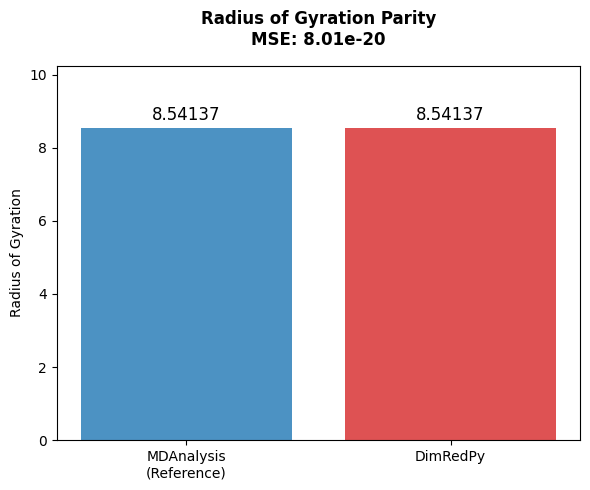

In [1]:
"""
Rigorous Verification of Descriptor Parity: Radius of Gyration
"""

import numpy as np
import os
import sys
import matplotlib.pyplot as plt

# Robust path detection for repo root
script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()
repo_root = os.path.abspath(os.path.join(script_dir, "..", ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import MDAnalysis as mda
from dimredpy.shared.descriptors import radius_of_gyration

# ---------------------------------------------------------------------------
# 1. Generate Synthetic Data
# ---------------------------------------------------------------------------
print("Generating synthetic atomic coordinates for Radius of Gyration parity...")
np.random.seed(42)
N_atoms = 1000
positions = np.random.randn(N_atoms, 3) * 5.0 # Random point cloud

# Create an empty MDAnalysis Universe with N atoms
u = mda.Universe.empty(N_atoms, trajectory=True)
u.add_TopologyAttr('masses', np.ones(N_atoms))
u.atoms.positions = positions

# ---------------------------------------------------------------------------
# 2. Run Reference Framework (MDAnalysis)
# ---------------------------------------------------------------------------
print("\n=======================================================")
print("          RUNNING REFERENCE FRAMEWORK (MDAnalysis)")
print("=======================================================")

rg_ref = u.atoms.radius_of_gyration()
print(f"-> MDAnalysis Rg: {rg_ref:.6f}")

# ---------------------------------------------------------------------------
# 3. Run DimRedPy Framework
# ---------------------------------------------------------------------------
print("\n=======================================================")
print("          RUNNING DIMREDPY FRAMEWORK")
print("=======================================================")

rg_dimredpy = radius_of_gyration(positions)
print(f"-> DimRedPy Rg: {rg_dimredpy:.6f}")

# ---------------------------------------------------------------------------
# 4. Parity Validation
# ---------------------------------------------------------------------------
print("\n=======================================================")
print("          PARITY VALIDATION")
print("=======================================================")

mse = (rg_ref - rg_dimredpy) ** 2

print(f"MSE on Radius of Gyration: {mse:.2e}")

if mse < 1e-10:
    print("\nSUCCESS: DimRedPy Radius of Gyration perfectly matches MDAnalysis reference.")
else:
    print("\nFAILURE: Statistical divergence detected in Rg parity.")

# ---------------------------------------------------------------------------
# 5. Visual Verification
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5), facecolor='white')

bars = ax.bar(['MDAnalysis\n(Reference)', 'DimRedPy'], [rg_ref, rg_dimredpy], color=['#1f77b4', '#d62728'], alpha=0.8)
ax.set_ylabel("Radius of Gyration")
ax.set_title(f"Radius of Gyration Parity\nMSE: {mse:.2e}", fontweight='bold', pad=15)
ax.set_ylim(0, max(rg_ref, rg_dimredpy) * 1.2)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.5f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plot_path = os.path.join(script_dir, "verify_parity_descriptors_rg_plot.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"Saved comparison plot to {plot_path}")
